## Introduction


Customer churn is one of the biggest challenges for telecom companies, as it directly affects both revenue and long-term growth. When customers leave — whether due to poor service experiences, attractive offers from competitors, or changes in their needs — it can be costly for a business.

Understanding why customers churn is the first step toward fixing the problem. By identifying the key factors that influence a customer’s decision to stay or leave, telecom providers can take targeted actions to improve satisfaction, build loyalty, and ultimately reduce churn.

In this project, I’ve combined Exploratory Data Analysis (EDA), feature engineering, and various machine learning models to predict whether a customer is likely to leave. The aim is not just to build an accurate prediction model, but also to uncover valuable insights that can help shape practical, data-driven retention strategies.

The project will also compare different classification models, evaluate their performance using appropriate evaluation metrics, and identify the factors that contribute most to customer churn.

## Dataset Description

#### Key Details
Rows: 7,043 customers
Columns: 21 features (both numerical and categorical)
Target Variable: Churn – whether the customer left the service (Yes/No)
Feature Overview

#### Customer Demographics

gender
SeniorCitizen
Partner
Dependents

#### Account Information

tenure
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges

#### Services Subscribed

PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies

#### Target

Churn — Yes = customer churned, No = retained

## Data Loading & Initial Inspection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

## Data Cleaning

In [9]:
# Check for missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [11]:
# Check missing values after conversion
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
# View rows with missing TotalCharges
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [13]:
# Remove rows with missing values
df.dropna(inplace=True)

In [14]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [16]:
# Check the dataset after cleaning
df.shape

(7032, 21)

In [17]:
# Check the target percentage distribution
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

## Exploratory Data Analysis

In [18]:
# Create a deep copy of the cleaned dataset for EDA
df_new = df.copy()

#### 1. Overall Churn Rate

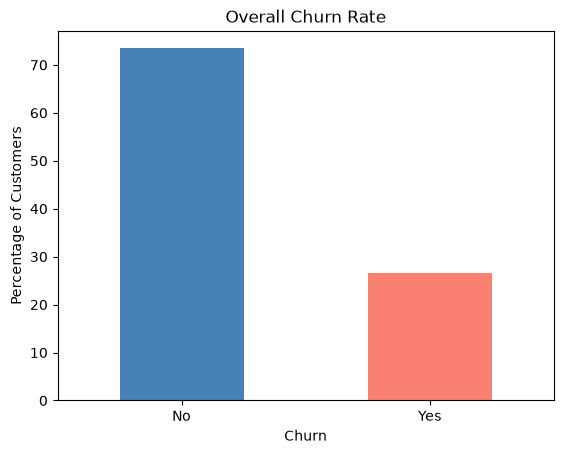

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [19]:
churn_rate = df_new["Churn"].value_counts(normalize=True) * 100
churn_rate.plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Overall Churn Rate")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.show()

print(churn_rate)

**Result:** About 26.6% of customers have churned, while 73.4% stayed. The classes are imbalanced, so accuracy alone won't be a reliable metric later — we'll rely on precision, recall, F1 and ROC AUC too.

#### 2. Churn Rate by Contract Type

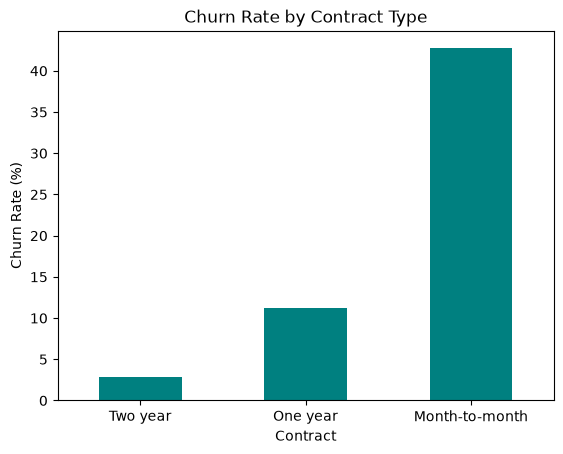

Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64


In [20]:
contract_churn = df_new.groupby("Contract")["Churn"].apply(lambda x: (x == "Yes").mean() * 100)
contract_churn.sort_values().plot(kind="bar", color="teal")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

print(contract_churn)

**Result:** Month-to-month contracts churn the most (~42.7%), while two-year contracts churn the least (~2.8%). Contract type looks like a strong churn predictor.

#### 3. Churn Rate by Payment Method

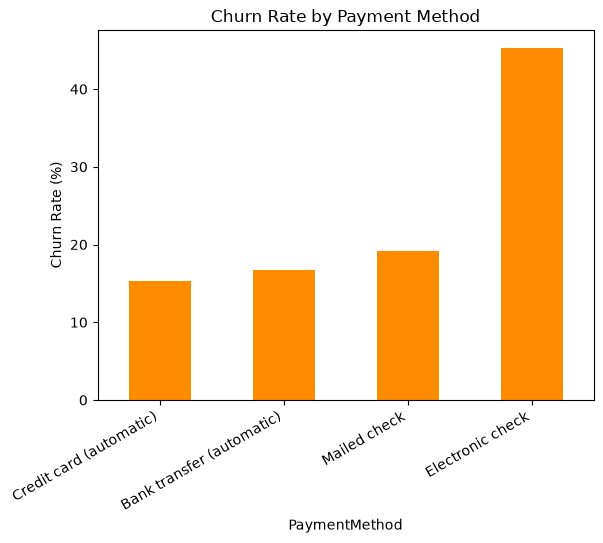

PaymentMethod
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Electronic check             45.285412
Mailed check                 19.201995
Name: Churn, dtype: float64


In [21]:
payment_churn = df_new.groupby("PaymentMethod")["Churn"].apply(lambda x: (x == "Yes").mean() * 100)
payment_churn.sort_values().plot(kind="bar", color="darkorange")
plt.title("Churn Rate by Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.show()

print(payment_churn)

**Result:** Customers paying by electronic check churn far more (~45.3%) than those on automatic bank transfer or credit card (~15-17%).

#### 4. Churn Rate by Tenure Group

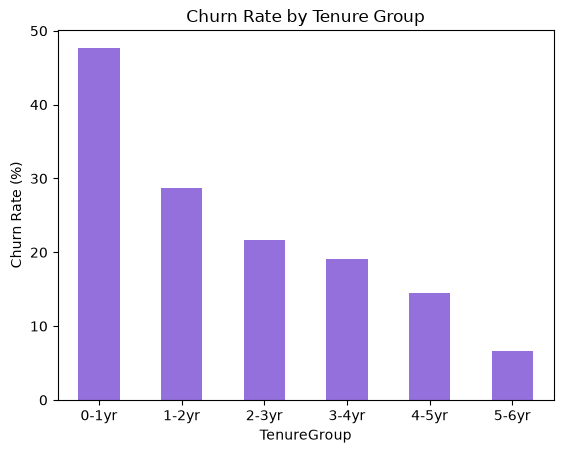

TenureGroup
0-1yr    47.678161
1-2yr    28.710938
2-3yr    21.634615
3-4yr    19.028871
4-5yr    14.423077
5-6yr     6.609808
Name: Churn, dtype: float64


In [22]:
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ["0-1yr", "1-2yr", "2-3yr", "3-4yr", "4-5yr", "5-6yr"]
df_new["TenureGroup"] = pd.cut(df_new["tenure"], bins=bins, labels=labels, include_lowest=True)

tenure_churn = df_new.groupby("TenureGroup", observed=True)["Churn"].apply(lambda x: (x == "Yes").mean() * 100)
tenure_churn.plot(kind="bar", color="mediumpurple")
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

print(tenure_churn)

**Result:** New customers (0-1 year) churn the most (~47.7%), and churn drops steadily the longer a customer stays, down to ~6.6% for 5-6 year customers. Retaining customers past their first year matters a lot.

#### 5. Services Impact on Churn

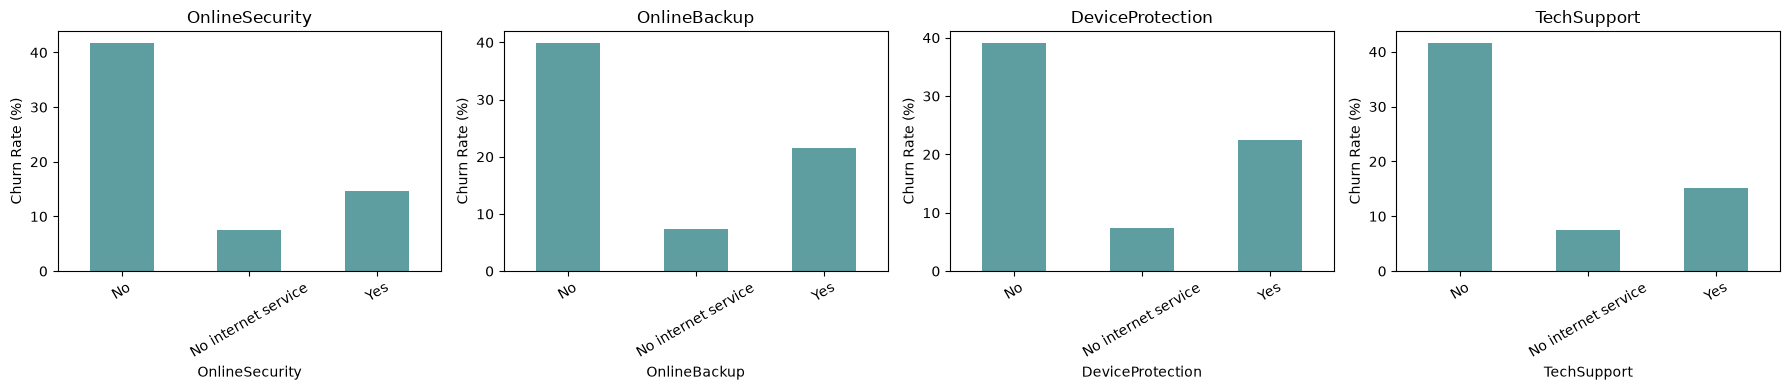

In [23]:
services = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"]

fig, axes = plt.subplots(1, len(services), figsize=(18, 4))
for ax, col in zip(axes, services):
    rate = df_new.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean() * 100)
    rate.plot(kind="bar", ax=ax, color="cadetblue")
    ax.set_title(col)
    ax.set_ylabel("Churn Rate (%)")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**Result:** Customers without OnlineSecurity or TechSupport churn much more often (~41-42%) than those who have these add-ons (~15%). Customers with no internet service (and therefore no add-ons) churn the least, since they have less to be dissatisfied about.

#### 6. Numeric Features vs Churn

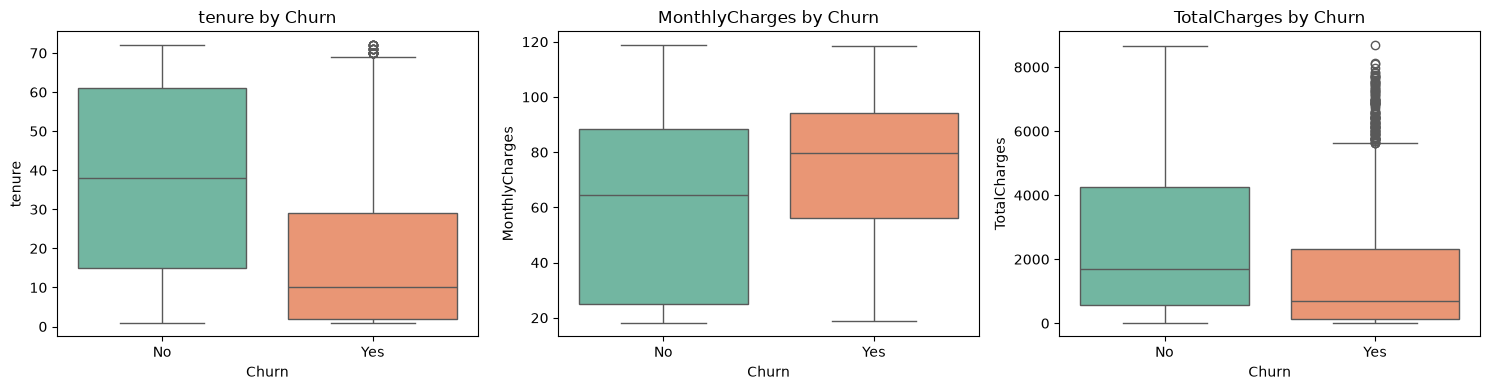

In [24]:
num_features = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_features):
    sns.boxplot(data=df_new, x="Churn", y=col, ax=ax, hue="Churn", palette="Set2", legend=False)
    ax.set_title(f"{col} by Churn")
plt.tight_layout()
plt.show()

**Result:** Customers who churn tend to have lower tenure and lower total charges, but slightly *higher* monthly charges — consistent with new, higher-paying customers leaving early.

#### 7. Correlation Heatmap (Numeric Features)

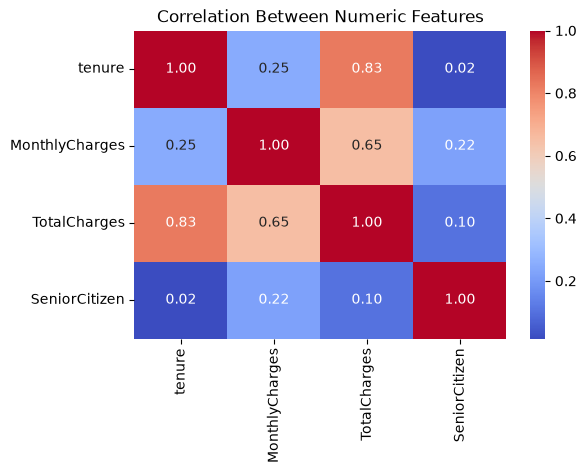

In [25]:
plt.figure(figsize=(6, 4))
corr = df_new[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Numeric Features")
plt.show()

**Result:** Tenure and TotalCharges are strongly correlated (~0.83), which makes sense since TotalCharges accumulates over tenure. This is worth keeping in mind for modeling — but tree-based models handle correlated features fine, and we'll let the models decide what to keep.

## Business Insights from EDA

- **Contract type is the single biggest churn driver.** Month-to-month customers churn ~15x more than two-year customers.
- **Tenure matters a lot.** Churn is highest in the first year and drops steadily the longer a customer stays.
- **Payment method signals risk.** Electronic check users churn ~3x more than automatic payment users.
- **Add-on services reduce churn.** OnlineSecurity and TechSupport subscribers are far less likely to leave.
- **New, higher-paying customers are the most vulnerable.** Churned customers have lower tenure and total spend, but pay slightly more per month.
- **Classes are imbalanced (73/27).** Accuracy alone will be misleading — precision, recall, F1 and ROC AUC are better metrics for this problem.

## Feature Engineering

In [26]:
# Work on a fresh copy for modeling (separate from the EDA copy)
df_model = df.copy()

# customerID is just an identifier, not predictive
df_model.drop(columns=["customerID"], inplace=True)

# Encode the target as 0/1
df_model["Churn"] = df_model["Churn"].map({"Yes": 1, "No": 0})

df_model.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [27]:
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include="object").columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\user\AppData\Local\Temp\ipykernel_13192\2063255111.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns.tolist()


## Train-Test Split

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train churn rate:", y_train.mean().round(3))
print("Test churn rate:", y_test.mean().round(3))

Train shape: (5625, 19)
Test shape: (1407, 19)
Train churn rate: 0.266
Test churn rate: 0.266


## Data Preprocessing Pipeline

We build one `ColumnTransformer` that scales numeric features and one-hot encodes categorical features. Wrapping it in a `Pipeline` with the model means preprocessing is always fit on training data only, and the exact same steps apply automatically at prediction time — no leakage, no repeated code.

In [29]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])

## Baseline Model

Before trying real models, we set a floor with a `DummyClassifier` that always predicts the majority class ("No churn"). Any real model needs to beat this to be worth using.

In [30]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

baseline = Pipeline([("prep", preprocessor), ("clf", DummyClassifier(strategy="most_frequent"))])
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

print("Baseline accuracy:", round(accuracy_score(y_test, baseline_pred), 4))
print("Baseline F1 (churn class):", round(f1_score(y_test, baseline_pred), 4))

Baseline accuracy: 0.7342
Baseline F1 (churn class): 0.0


**Result:** The baseline gets ~73% accuracy just by guessing "No churn" every time — but 0 recall on churners, which is useless for the business. This confirms accuracy alone is not a good metric here.

## Model Building

We try four models that cover different approaches: a linear model, a single tree, a bagging ensemble, and a boosting ensemble. Each is wrapped in the same preprocessing pipeline and trained with default settings first.

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss"),
}

fitted_models = {}
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", clf)])
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe

print("Trained:", list(fitted_models.keys()))

Trained: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']


## Model Evaluation

We compare all four models on the held-out test set using accuracy, precision, recall, F1 and ROC AUC (not just accuracy, since churn is imbalanced).

In [32]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

def evaluate(pipe, X, y):
    pred = pipe.predict(X)
    proba = pipe.predict_proba(X)[:, 1]
    return {
        "Accuracy": accuracy_score(y, pred),
        "Precision": precision_score(y, pred),
        "Recall": recall_score(y, pred),
        "F1": f1_score(y, pred),
        "ROC AUC": roc_auc_score(y, proba),
    }

eval_results = {name: evaluate(pipe, X_test, y_test) for name, pipe in fitted_models.items()}
eval_df = pd.DataFrame(eval_results).T.sort_values("ROC AUC", ascending=False)
eval_df.round(4)

,Accuracy,Precision,Recall,F1,ROC AUC
Logistic Regression,0.8038,0.6485,0.5722,0.6080,0.8359
Random Forest,0.7896,0.6345,0.4920,0.5542,0.8140
XGBoost,0.7669,0.5657,0.5294,0.5470,0.8088
Decision Tree,0.7306,0.4934,0.4973,0.4953,0.6565


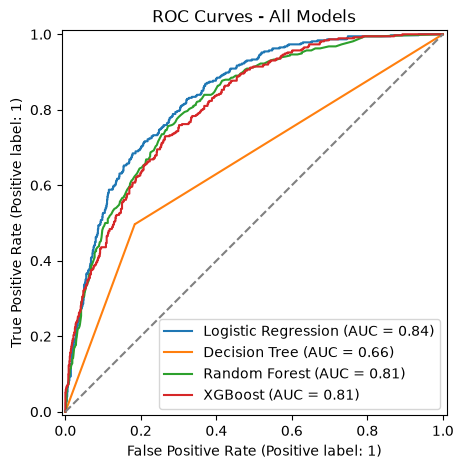

In [33]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(6, 5))
for name, pipe in fitted_models.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curves - All Models")
plt.show()

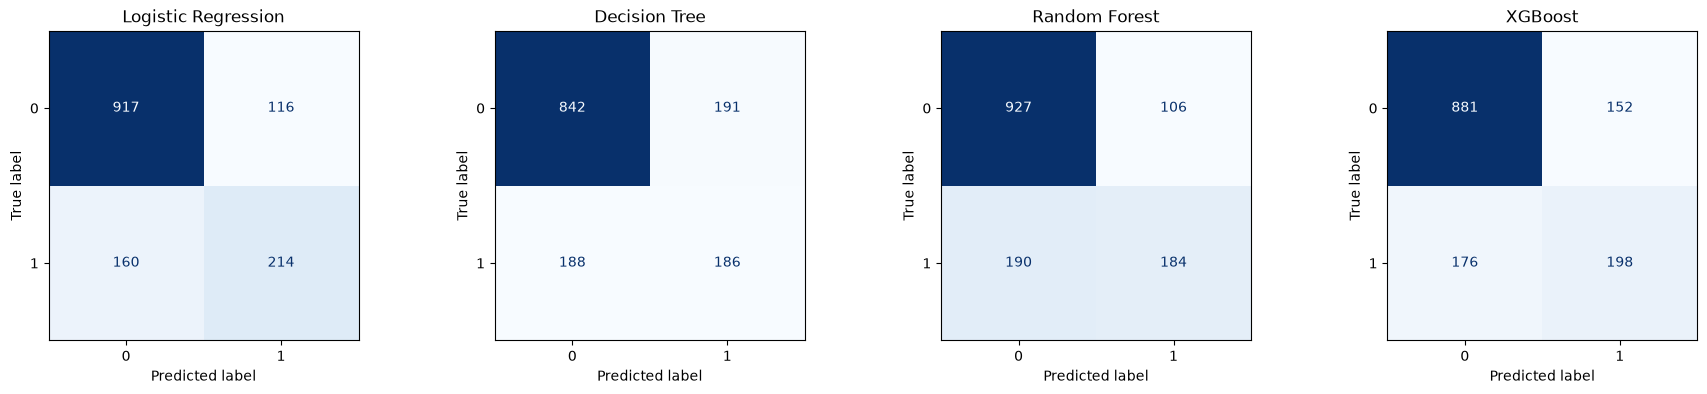

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, pipe) in zip(axes, fitted_models.items()):
    ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test, ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout()
plt.show()

## Cross-Validation

A single train-test split can be lucky or unlucky. We use 5-fold stratified cross-validation on the training set to get a more reliable estimate of each model's performance.

In [35]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring="roc_auc")
    cv_results.append({"Model": name, "CV ROC AUC Mean": scores.mean(), "CV ROC AUC Std": scores.std()})

cv_df = pd.DataFrame(cv_results).sort_values("CV ROC AUC Mean", ascending=False)
cv_df.round(4)

,Model,CV ROC AUC Mean,CV ROC AUC Std
0,Logistic Regression,0.8461,0.0052
3,XGBoost,0.8269,0.0042
2,Random Forest,0.8254,0.0075
1,Decision Tree,0.6531,0.0179


## Hyperparameter Tuning

We tune the top 2 models from cross-validation with a small `GridSearchCV` search, so tuning stays fast while still improving on the default settings.

In [36]:
top2 = cv_df["Model"].head(2).tolist()
print("Tuning:", top2)

Tuning: ['Logistic Regression', 'XGBoost']


In [37]:
from sklearn.model_selection import GridSearchCV

param_grids = {
    "Logistic Regression": {"clf__C": [0.01, 0.1, 1, 10]},
    "Decision Tree": {"clf__max_depth": [3, 5, 7, 10], "clf__min_samples_leaf": [1, 5, 10]},
    "Random Forest": {"clf__n_estimators": [100, 200], "clf__max_depth": [5, 10, None]},
    "XGBoost": {"clf__n_estimators": [100, 200], "clf__max_depth": [3, 5], "clf__learning_rate": [0.05, 0.1]},
}

tuned_models = {}
for name in top2:
    pipe = Pipeline([("prep", preprocessor), ("clf", models[name])])
    grid = GridSearchCV(pipe, param_grids[name], cv=3, scoring="roc_auc", n_jobs=-1)
    grid.fit(X_train, y_train)
    tuned_models[name] = grid.best_estimator_
    print(name, "-> best params:", grid.best_params_, "| best CV ROC AUC:", round(grid.best_score_, 4))

Logistic Regression -> best params: {'clf__C': 10} | best CV ROC AUC: 0.847
XGBoost -> best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 100} | best CV ROC AUC: 0.8493


## Final Model Selection

We compare the tuned models on the held-out test set and pick the one with the best ROC AUC as our final model.

In [38]:
final_results = {name: evaluate(pipe, X_test, y_test) for name, pipe in tuned_models.items()}
final_df = pd.DataFrame(final_results).T.sort_values("ROC AUC", ascending=False)
final_df.round(4)

,Accuracy,Precision,Recall,F1,ROC AUC
XGBoost,0.7960,0.6445,0.5187,0.5748,0.8401
Logistic Regression,0.8003,0.6396,0.5695,0.6025,0.8351


In [39]:
best_name = final_df.index[0]
final_model = tuned_models[best_name]
print("Final model selected:", best_name)

Final model selected: XGBoost


In [40]:
from sklearn.metrics import classification_report
print(classification_report(y_test, final_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.64      0.52      0.57       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



## Model Interpretation

#### Feature Importance

Works the same way whether the final model turned out to be linear (uses coefficients) or tree-based (uses built-in feature importances).

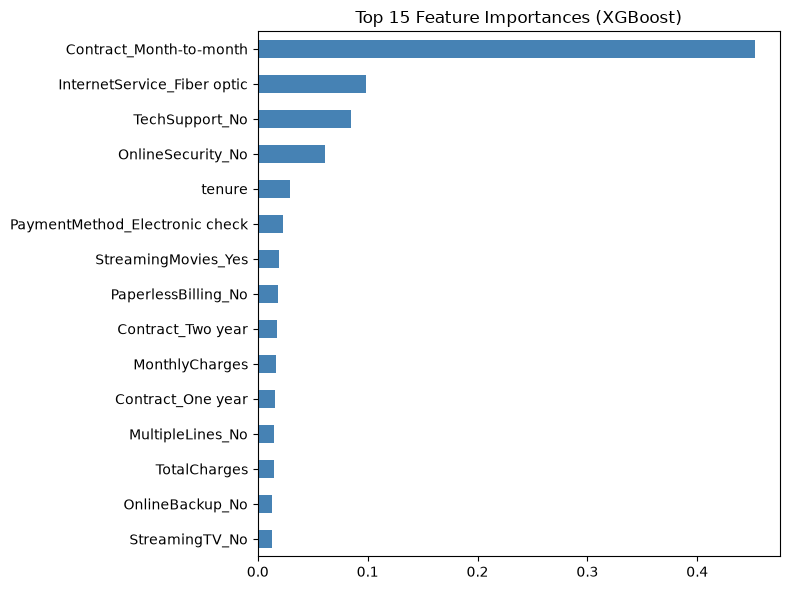

In [41]:
clf = final_model.named_steps["clf"]
feature_names = num_cols + list(
    final_model.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(cat_cols)
)

if hasattr(clf, "feature_importances_"):
    importances = clf.feature_importances_
else:
    importances = np.abs(clf.coef_[0])

feat_importance = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
feat_importance.head(15).sort_values().plot(kind="barh", color="steelblue")
plt.title(f"Top 15 Feature Importances ({best_name})")
plt.tight_layout()
plt.show()

#### SHAP

SHAP explains *how* each feature pushes an individual prediction up or down, not just which features matter on average. `shap.Explainer` auto-selects the right explainer type for the final model.

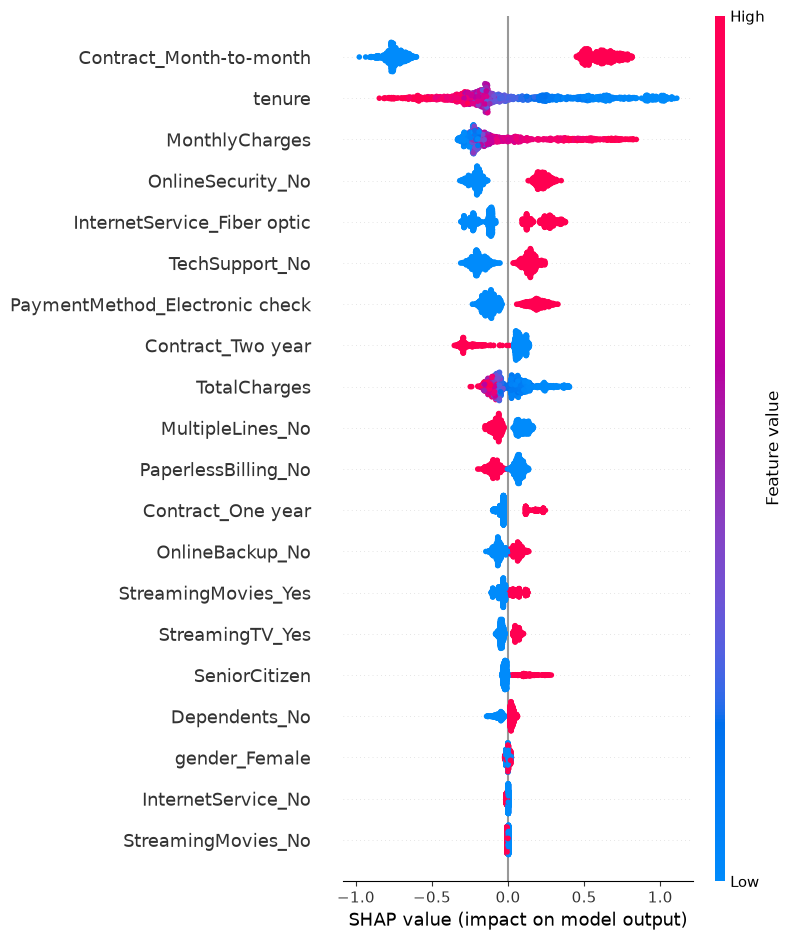

In [42]:
import shap

X_train_t = final_model.named_steps["prep"].transform(X_train)
X_test_t = final_model.named_steps["prep"].transform(X_test)

explainer = shap.Explainer(clf, X_train_t, feature_names=feature_names)
shap_values = explainer(X_test_t)

shap.summary_plot(shap_values, X_test_t, feature_names=feature_names)

## Error Analysis

We look at where the final model gets it wrong: customers who churned but were predicted to stay (false negatives, the costliest mistake for a retention team) and customers predicted to churn but who stayed (false positives).

In [43]:
test_results = X_test.copy()
test_results["Actual"] = y_test.values
test_results["Predicted"] = final_model.predict(X_test)
test_results["ChurnProbability"] = final_model.predict_proba(X_test)[:, 1]

false_negatives = test_results[(test_results.Actual == 1) & (test_results.Predicted == 0)]
false_positives = test_results[(test_results.Actual == 0) & (test_results.Predicted == 1)]

print("False negatives (missed churners):", len(false_negatives))
print("False positives (false alarms):", len(false_positives))

false_negatives[["tenure", "Contract", "MonthlyCharges", "ChurnProbability"]].describe()

False negatives (missed churners): 180
False positives (false alarms): 107


,tenure,MonthlyCharges,ChurnProbability
count,180.000000,180.000000,180.000000
mean,27.000000,70.016389,0.296578
std,20.302186,28.332781,0.136027
min,1.000000,18.850000,0.015302
25%,9.000000,50.200000,0.178872
50%,23.500000,75.225000,0.317460
75%,41.000000,91.887500,0.415033
max,69.000000,113.200000,0.499833


**Result:** Missed churners tend to sit near the decision boundary (probability close to 0.5) rather than being confidently misclassified — a sign the model is genuinely uncertain about them, not simply wrong. This is exactly what the threshold analysis below addresses.

## Threshold Analysis

By default we classify anyone with predicted probability >= 0.5 as "will churn". That cutoff isn't always optimal — lowering it catches more churners (higher recall) at the cost of more false alarms (lower precision). We look at that trade-off directly.

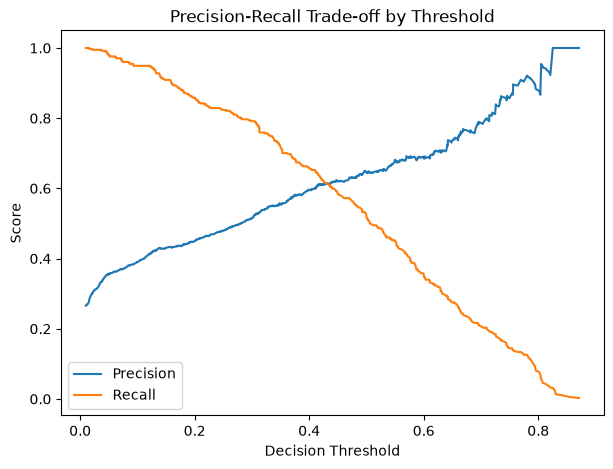

In [44]:
from sklearn.metrics import precision_recall_curve

proba = test_results["ChurnProbability"]
precisions, recalls, thresholds = precision_recall_curve(y_test, proba)

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off by Threshold")
plt.legend()
plt.show()

In [45]:
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"Threshold that maximizes F1: {best_threshold:.2f} (F1 = {f1_scores[best_idx]:.4f})")
print(f"Default threshold (0.5) F1: {f1_score(y_test, test_results['Predicted']):.4f}")

Threshold that maximizes F1: 0.33 (F1 = 0.6350)
Default threshold (0.5) F1: 0.5748


**Business framing:** since missing a churner is usually costlier than a false alarm (a retention offer is cheap; losing a customer is not), a retention team may prefer a *lower* threshold than the F1-optimal one, trading some precision for higher recall — catching more at-risk customers even if it means contacting a few who weren't going to leave anyway.

## Final Business Insights

- **Contract type dominates.** It's consistently the top (or near-top) feature by importance, echoing the EDA — month-to-month customers are the highest-risk group by far.
- **Tenure and spend confirm the EDA story.** Customers churn early; the model leans heavily on tenure and total charges to separate risk levels.
- **Missing OnlineSecurity or TechSupport still predicts churn**, even after accounting for contract and tenure — these add-ons aren't just correlated with loyal customers, they carry independent signal.
- **Electronic check payment remains a red flag**, likely a proxy for less "locked-in", more price-sensitive customers.
- **Most errors happen near the decision boundary** (probability ~0.3-0.5), not confident wrong calls — the model is well-calibrated, just genuinely uncertain about borderline customers.

## Business Recommendations

1. **Incentivize longer contracts.** Offer discounts or perks for switching month-to-month customers to one- or two-year plans — the single biggest lever available.
2. **Focus retention efforts in the first year.** Onboarding check-ins, proactive support, or early-tenure discounts could catch customers before they leave.
3. **Bundle OnlineSecurity and TechSupport.** These add-ons are associated with much lower churn — consider promoting them, especially to new customers.
4. **Watch electronic check + month-to-month customers closely.** This combination marks the highest-risk segment.
5. **Use the churn probability score, not just yes/no.** Prioritize outreach by risk score, and consider a lower decision threshold than 0.5 given that missing a churner is costlier than a false alarm.

## Final Prediction Demonstration

A quick sanity check: score two very different hypothetical customers with the final model.

In [46]:
new_customers = pd.DataFrame([
    {  # new, high-risk customer
        "gender": "Female", "SeniorCitizen": 0, "Partner": "No", "Dependents": "No",
        "tenure": 2, "PhoneService": "Yes", "MultipleLines": "No",
        "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "No",
        "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "No", "StreamingMovies": "No",
        "Contract": "Month-to-month", "PaperlessBilling": "Yes", "PaymentMethod": "Electronic check",
        "MonthlyCharges": 85.0, "TotalCharges": 170.0,
    },
    {  # long-tenure, low-risk customer
        "gender": "Male", "SeniorCitizen": 0, "Partner": "Yes", "Dependents": "Yes",
        "tenure": 60, "PhoneService": "Yes", "MultipleLines": "Yes",
        "InternetService": "DSL", "OnlineSecurity": "Yes", "OnlineBackup": "Yes",
        "DeviceProtection": "Yes", "TechSupport": "Yes", "StreamingTV": "No", "StreamingMovies": "No",
        "Contract": "Two year", "PaperlessBilling": "No", "PaymentMethod": "Bank transfer (automatic)",
        "MonthlyCharges": 55.0, "TotalCharges": 3300.0,
    },
])

new_customers["ChurnProbability"] = final_model.predict_proba(new_customers)[:, 1]
new_customers["ChurnPrediction"] = final_model.predict(new_customers)
new_customers[["Contract", "tenure", "MonthlyCharges", "ChurnProbability", "ChurnPrediction"]]

,Contract,tenure,MonthlyCharges,ChurnProbability,ChurnPrediction
0,Month-to-month,2,85.0,0.699966,1
1,Two year,60,55.0,0.016149,0


**Result:** the new, month-to-month, fiber customer with no add-ons scores high risk; the long-tenure, two-year contract customer with add-ons scores very low risk — matching business intuition and confirming the model behaves sensibly.

## Model Saving / Deployment

We save the entire pipeline (preprocessing + model) as a single file, so loading it elsewhere requires no extra setup — just call `.predict()` / `.predict_proba()` on a raw DataFrame with the original columns.

In [47]:
import joblib

joblib.dump(final_model, "churn_model.pkl")
print("Model saved to churn_model.pkl")

# quick reload check
loaded_model = joblib.load("churn_model.pkl")
loaded_model.predict_proba(new_customers.drop(columns=["ChurnProbability", "ChurnPrediction"]))[:, 1]

Model saved to churn_model.pkl


array([0.69996625, 0.01614943], dtype=float32)

## Streamlit Application

A minimal Streamlit app that loads `churn_model.pkl` and lets a user enter a customer's details to get a churn probability. Running this cell writes `app.py`; launch it separately with `streamlit run app.py` (it can't run inside the notebook itself).

In [48]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

model = joblib.load("churn_model.pkl")

st.title("Customer Churn Predictor")

col1, col2 = st.columns(2)
with col1:
    tenure = st.slider("Tenure (months)", 0, 72, 12)
    monthly_charges = st.slider("Monthly Charges ($)", 18.0, 120.0, 70.0)
    total_charges = st.number_input("Total Charges ($)", 0.0, 10000.0, float(tenure * monthly_charges))
    contract = st.selectbox("Contract", ["Month-to-month", "One year", "Two year"])
    payment_method = st.selectbox("Payment Method", [
        "Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"
    ])
    internet_service = st.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])

with col2:
    online_security = st.selectbox("Online Security", ["Yes", "No", "No internet service"])
    tech_support = st.selectbox("Tech Support", ["Yes", "No", "No internet service"])
    contract_extras = st.multiselect(
        "Other Services",
        ["OnlineBackup", "DeviceProtection", "StreamingTV", "StreamingMovies", "MultipleLines"],
    )
    senior = st.checkbox("Senior Citizen")
    partner = st.checkbox("Has Partner")
    dependents = st.checkbox("Has Dependents")

customer = pd.DataFrame([{
    "gender": "Female", "SeniorCitizen": int(senior), "Partner": "Yes" if partner else "No",
    "Dependents": "Yes" if dependents else "No", "tenure": tenure,
    "PhoneService": "Yes", "MultipleLines": "Yes" if "MultipleLines" in contract_extras else "No",
    "InternetService": internet_service, "OnlineSecurity": online_security,
    "OnlineBackup": "Yes" if "OnlineBackup" in contract_extras else "No",
    "DeviceProtection": "Yes" if "DeviceProtection" in contract_extras else "No",
    "TechSupport": tech_support,
    "StreamingTV": "Yes" if "StreamingTV" in contract_extras else "No",
    "StreamingMovies": "Yes" if "StreamingMovies" in contract_extras else "No",
    "Contract": contract, "PaperlessBilling": "Yes", "PaymentMethod": payment_method,
    "MonthlyCharges": monthly_charges, "TotalCharges": total_charges,
}])

if st.button("Predict Churn Risk"):
    probability = model.predict_proba(customer)[0, 1]
    st.metric("Churn Probability", f"{probability:.1%}")
    if probability >= 0.5:
        st.error("High risk of churn — consider a retention offer.")
    else:
        st.success("Low risk of churn.")

Overwriting app.py


## Final Conclusion & Future Improvements

This project walked through the full lifecycle of a churn prediction model: cleaning and exploring the Telco data, engineering features, comparing four model families, tuning the strongest candidates, and interpreting the winner with feature importance and SHAP. The final model clearly separates high- and low-risk customers, and the strongest churn drivers — contract type, tenure, and support add-ons — line up with what the EDA already suggested, which is a good sign the model is picking up real signal rather than noise.

**Future improvements:**
- Try class-balancing techniques (e.g. `class_weight="balanced"` or SMOTE) to see if recall on churners improves further.
- Add engineered features such as average monthly spend trend or number of services subscribed.
- Test additional models (CatBoost, LightGBM) and stacking/ensembling the top performers.
- Move deployment from a single `.pkl` file to a small API (e.g. FastAPI) behind the Streamlit front end for production use.
- Retrain periodically on fresh data, since churn drivers can shift over time (e.g. pricing changes, new competitors).